## Setup

In [1]:
%load_ext autoreload
%autoreload 2

Set up the working environment:

In [2]:
# To ensure reproducibility
seed = 7214

# Import path libraries
import os
import sys
import pathlib

# Define paths
project_path = pathlib.Path(r"C:\Users\Miguel\Desarrollo\TFM")
data_path = project_path / "data" / "clean" / "whole_clinical_data.parquet"
results_path = project_path / "results" / "models" / "whole_clinical_data"

# Add the project path to sys.path if it's not already there
if str(project_path) not in sys.path:
    sys.path.append(str(project_path))

print(f"Loading data from: {data_path}")
print(f"Saving results to: {results_path}")

Loading data from: C:\Users\Miguel\Desarrollo\TFM\data\clean\whole_clinical_data.parquet
Saving results to: C:\Users\Miguel\Desarrollo\TFM\results\models\whole_clinical_data


Load libraries:

In [3]:
# DATA WRANGLING, STATISTICS
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy.stats import uniform, randint, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, 
                            ExtraTreesClassifier, 
                            AdaBoostClassifier, 
                            GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# CUSTOM MODULES
from src.models import *

## Data

Load the data:

In [4]:
# Load data
df = pd.read_parquet(data_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   720 non-null    object 
 1   age                   720 non-null    float64
 2   smoking_status        720 non-null    object 
 3   code                  720 non-null    float64
 4   center                720 non-null    object 
 5   intervention          720 non-null    object 
 6   BMI                   720 non-null    float64
 7   Met                   720 non-null    float64
 8   glucose               690 non-null    float64
 9   type1_diabetes        720 non-null    object 
 10  type2_diabetes        720 non-null    object 
 11  HDL                   646 non-null    float64
 12  triglicerides         650 non-null    float64
 13  hypercholesterolemia  720 non-null    object 
 14  OSA                   720 non-null    object 
 15  renal_insuf           720 non-null

Let's transform the categorical features `object` data type into `category` and check their values:

In [5]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    print(f"Categories of column '{col}': {df[col].cat.categories.tolist()}")

Categories of column 'sex': ['female', 'male']
Categories of column 'smoking_status': ['current', 'former', 'never']
Categories of column 'center': ['Alicante', 'Granada', 'Madrid', 'Pamplona']
Categories of column 'intervention': ['control', 'intervention']
Categories of column 'type1_diabetes': ['no', 'yes']
Categories of column 'type2_diabetes': ['no', 'yes']
Categories of column 'hypercholesterolemia': ['no', 'yes']
Categories of column 'OSA': ['no', 'yes']
Categories of column 'renal_insuf': ['no', 'yes']
Categories of column 'hypertension': ['no', 'yes']
Categories of column 'COPD': ['no', 'yes']
Categories of column 'stroke': ['no', 'yes']
Categories of column 'cardiomyopathy': ['no', 'yes']
Categories of column 'antirrythmic_meds': ['no', 'yes']
Categories of column 'LA_enlargment': ['mild', 'moderate', 'normal', 'severe']
Categories of column 'LVEF': ['moderately abnormal', 'normal', 'severely abnormal', 'slightly abnormal']
Categories of column 'AF_type': ['paroxysmal', 'pers

Since there are some categorical features where their categories are randomly arranged, they need to be manually rearranged in order to encode them properly:

In [6]:
# Rearrange categories manually
df['sex'] = df['sex'].astype(CategoricalDtype(categories=["male", "female"], ordered=True))
df['smoking_status'] = df['smoking_status'].astype(CategoricalDtype(categories=["never", "former", "current"], ordered=True))
df['LA_enlargment'] = df['LA_enlargment'].astype(CategoricalDtype(categories=["normal", "mild", "moderate", "severe"], ordered=True))
df['LVEF'] = df['LVEF'].astype(CategoricalDtype(categories=["normal", "slightly abnormal", "moderately abnormal", "severely abnormal"], ordered=True))


Separate the features from the target class:

In [7]:
# Drop the target class and the non-informative features
X = df.drop([
    "code",
    "center",
    "AF_recurrence", 
    "hatch_score"
            ], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train ($80 \%$) and test ($20 \%$) sets :

In [8]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

## HATCH score evaluation

In [9]:
# Filter the patients belonging to the test group
df_test = df.loc[X_test.index]

# Get the the scores
# y_test has been already calculated
y_scores_hatch = df_test["hatch_score"]

# Compute the ROC curve and AUC
fpr_hatch, tpr_hatch, _ = roc_curve(y_test, y_scores_hatch)
roc_auc_hatch = roc_auc_score(y_test, y_scores_hatch)
print(f"ROC-AUC for HATCH score: {roc_auc_hatch:.4f}")

# Compute the PR curve and AUC
precs_hatch, recs_hatch, _ = precision_recall_curve(y_test, y_scores_hatch)
pr_auc_hatch = average_precision_score(y_test, y_scores_hatch)
print(f"PR-AUC for HATCH score: {pr_auc_hatch:.4f}")

ROC-AUC for HATCH score: 0.5347
PR-AUC for HATCH score: 0.4174


## Training and optimization

Training each model with stratified 5-fold cross validation:

In [10]:
# Number of splits
n = 5

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n, shuffle=True, random_state=42)

Define metrics to evaluate:

In [11]:
# Set up the scoring dictionary for cross-validation
scoring_dict = {
        'ROC-AUC': 'roc_auc',
        'PR-AUC': 'average_precision'
    }

objective_metric = "PR-AUC"

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [12]:
# Hyperparameters search space
params_EN = {
    'clf__l1_ratio': uniform(0, 1),
    'clf__C': loguniform(1e-4, 1e3)
    }

# Get the preprocessor
preprocessor_EN = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed, solver='saga', max_iter=10000))
])

Train and optimize the model:

In [13]:
(
optimized_EN, 
cv_results_EN,
fpr_EN, tpr_EN,
precs_EN, recs_EN
) = optimize_model_random_search(
    pipeline=pipe_EN, 
    param_distributions=params_EN, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    aim=scoring_dict[objective_metric],
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [14]:
save_model(fitted_pipeline=optimized_EN, output_dir=results_path, identifier="EN")

,Hyperparameter,Optimal Value
1,C,0.115161
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,0.946275
6,max_iter,10000
7,penalty,deprecated
8,random_state,7214
9,solver,saga
10,tol,0.0001


Check the overfitting:

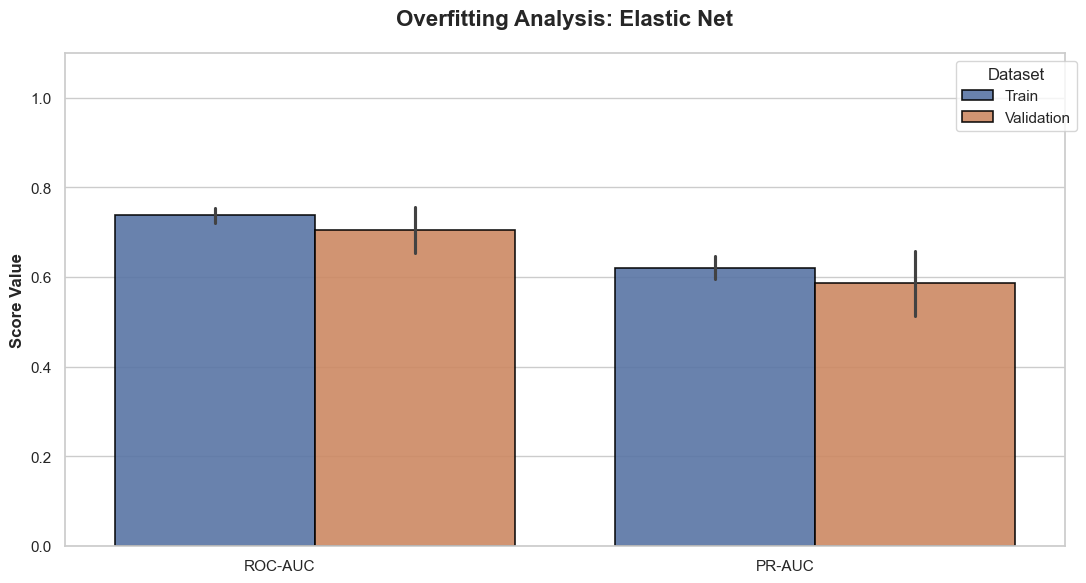

In [15]:
plot_overfitting_bars(df_cv_results=cv_results_EN, 
                    title="Elastic Net", 
                    output_dir=results_path, 
                    identifier="EN")

Take a look at the relevant columns:

In [16]:
relevant_cols_EN, irrelevant_cols_EN = get_relevant_features(optimized_EN)

print("relevant features: ", relevant_cols_EN)
print("\n")
print("irrelevant features: ", irrelevant_cols_EN)

relevant features:  ['ERAF', 'AF_type', 'AF_ablation_time', 'sex', 'stroke', 'previous_ablation', 'hypertension', 'intervention', 'Met', 'age', 'cardiomyopathy', 'OSA', 'antirrythmic_meds']


irrelevant features:  ['BMI', 'glucose', 'HDL', 'triglicerides', 'smoking_status', 'type1_diabetes', 'type2_diabetes', 'hypercholesterolemia', 'renal_insuf', 'COPD', 'LA_enlargment', 'LVEF']


#### Support Vector Machine

Define the parameter distributions and set up the pipeline:

In [17]:
# Hyperparameters search space
params_dist_SVM = {
    'clf__C': loguniform(1e-5, 1e3),
    'clf__kernel': ['linear', 'rbf', 'poly'],
    'clf__gamma': ['scale', 'auto'],
    'clf__degree': randint(2, 4),
    'clf__class_weight': [None, 'balanced']
}

# Get preprocessor
preprocessor_SVM = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed, max_iter=10000))
])

Train and optimize the model:

In [18]:
(
optimized_SVM, 
cv_results_SVM,
fpr_SVM, tpr_SVM,
precs_SVM, recs_SVM
) = optimize_model_random_search(
    pipeline=pipe_SVM, 
    param_distributions=params_dist_SVM, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [19]:
save_model(fitted_pipeline=optimized_SVM, output_dir=results_path, identifier="SVM")

,Hyperparameter,Optimal Value
1,C,0.000067
2,break_ties,False
3,cache_size,200
4,coef0,0.0
5,decision_function_shape,ovr
6,degree,2
7,gamma,scale
8,kernel,linear
9,max_iter,10000
10,probability,deprecated


Check the overfitting:

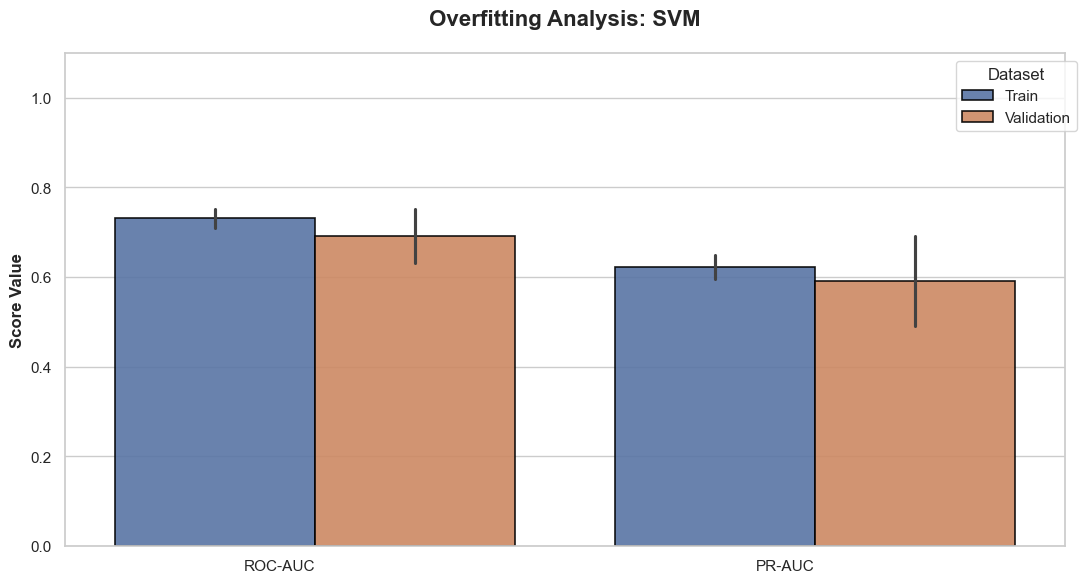

In [20]:
plot_overfitting_bars(df_cv_results=cv_results_SVM, 
                    title="SVM", 
                    output_dir=results_path, 
                    identifier="SVM")

Take a look at the relevant columns:

In [21]:
relevant_cols_SVM, irrelevant_cols_SVM = get_relevant_features(optimized_SVM)

print("relevant features: ", relevant_cols_SVM)
print("\n")
print("irrelevant features: ", irrelevant_cols_SVM)

relevant features:  ['ERAF', 'AF_ablation_time', 'previous_ablation', 'AF_type', 'stroke', 'sex', 'Met', 'BMI', 'OSA', 'hypertension', 'antirrythmic_meds', 'intervention', 'LVEF', 'glucose', 'age', 'LA_enlargment', 'HDL', 'renal_insuf', 'smoking_status', 'cardiomyopathy', 'COPD', 'type2_diabetes', 'type1_diabetes', 'triglicerides', 'hypercholesterolemia']


irrelevant features:  []


#### Decision Tree

Define the parameter distributions and set up the pipeline:

In [22]:
# Hyperparameters search space
params_dist_DT = {
    'clf__max_depth': randint(2, 33),
    'clf__max_features': ['sqrt', 'log2', None],
    'clf__min_samples_split': randint(2, 21),
    'clf__criterion': ['gini', 'entropy'],
}

# Get the preprocessor
preprocessor_DT = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_DT = Pipeline(steps=[
    ('preprocessor', preprocessor_DT),
    ('clf', DecisionTreeClassifier(random_state=seed))
])

Train and optimize the model:

In [23]:
(
optimized_DT, 
cv_results_DT,
fpr_DT, tpr_DT,
precs_DT, recs_DT
) = optimize_model_random_search(
    pipeline=pipe_DT, 
    param_distributions=params_dist_DT, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [24]:
save_model(fitted_pipeline=optimized_DT, output_dir=results_path, identifier="DT")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,entropy
3,max_depth,4
4,max_features,log2
5,min_impurity_decrease,0.0
6,min_samples_leaf,1
7,min_samples_split,15
8,min_weight_fraction_leaf,0.0
9,random_state,7214
10,splitter,best


Check the overfitting:

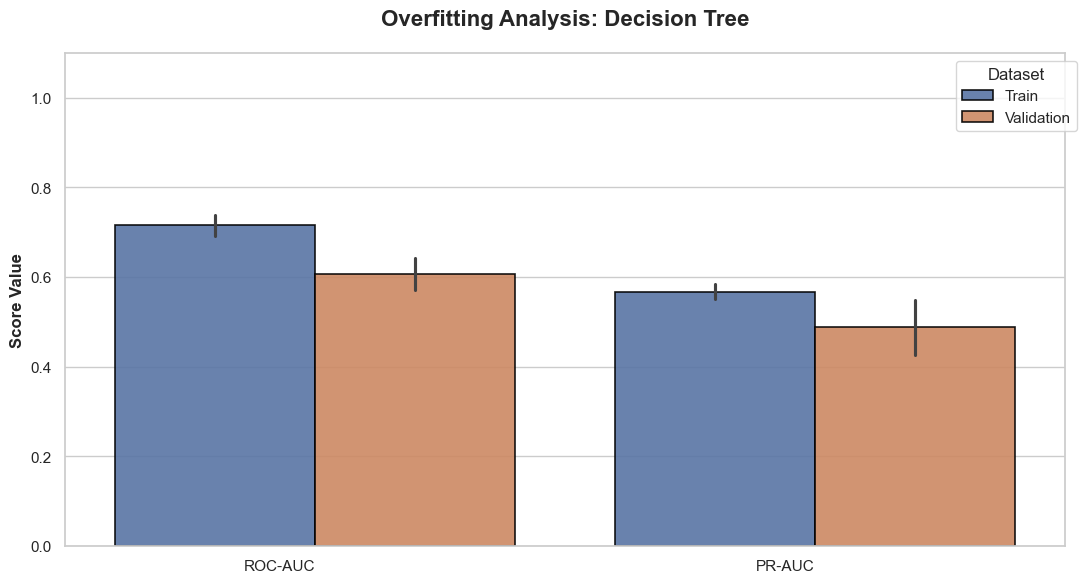

In [25]:
plot_overfitting_bars(df_cv_results=cv_results_DT, 
                    title="Decision Tree", 
                    output_dir=results_path, 
                    identifier="DT")

#### Random Forest

Define the parameter distributions and set up the pipeline:

In [26]:
# Hyperparameters search space
params_dist_RF = {
    'clf__n_estimators': randint(20, 301),
    'clf__max_depth': randint(2, 33),
    'clf__max_features': ['sqrt', 'log2', None],
    'clf__min_samples_split': randint(2, 21),
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

# Get the preprocessor
preprocessor_RF = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

Train and optimize the model:

In [27]:
(
optimized_RF, 
cv_results_RF,
fpr_RF, tpr_RF,
precs_RF, recs_RF
) = optimize_model_random_search(
    pipeline=pipe_RF, 
    param_distributions=params_dist_RF, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [28]:
save_model(fitted_pipeline=optimized_RF, output_dir=results_path, identifier="RF")

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,criterion,entropy
4,max_depth,2
5,min_impurity_decrease,0.0
6,min_samples_leaf,1
7,min_samples_split,17
8,min_weight_fraction_leaf,0.0
9,n_estimators,132
10,oob_score,False


Check the overfitting:

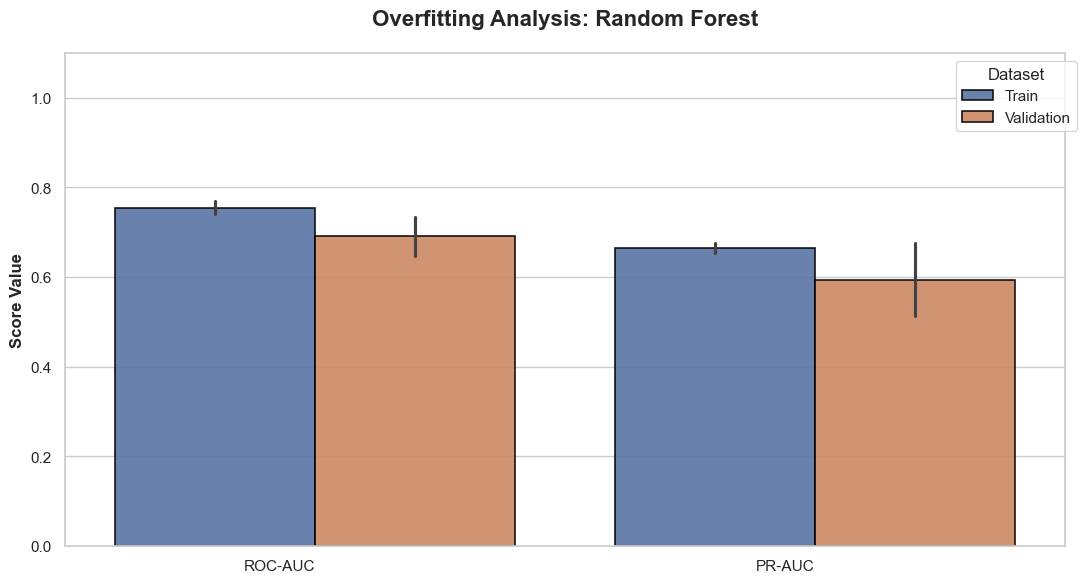

In [29]:
plot_overfitting_bars(df_cv_results=cv_results_RF, 
                    title="Random Forest", 
                    output_dir=results_path, 
                    identifier="RF")

#### Extra Trees


Define the parameter distributions and set up the pipeline:


In [30]:
# Hyperparameters search space
params_dist_ET = {
    'clf__n_estimators': randint(20, 301),
    'clf__max_depth': randint(2, 33),
    'clf__max_features': ['sqrt', 'log2', None],
    'clf__min_samples_split': randint(2, 21),
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

# Get the preprocessor (using the same as RF)
preprocessor_ET = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor_ET),
    ('clf', ExtraTreesClassifier(random_state=seed))
])

Train and optimize the model:


In [31]:
(
optimized_ET, 
cv_results_ET,
fpr_ET, tpr_ET,
precs_ET, recs_ET
) = optimize_model_random_search(
    pipeline=pipe_ET, 
    param_distributions=params_dist_ET, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:


In [32]:
save_model(fitted_pipeline=optimized_ET, output_dir=results_path, identifier="ET")


,Hyperparameter,Optimal Value
1,bootstrap,False
2,ccp_alpha,0.0
3,criterion,gini
4,max_depth,6
5,max_features,log2
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,14
9,min_weight_fraction_leaf,0.0
10,n_estimators,297


Check the overfitting:


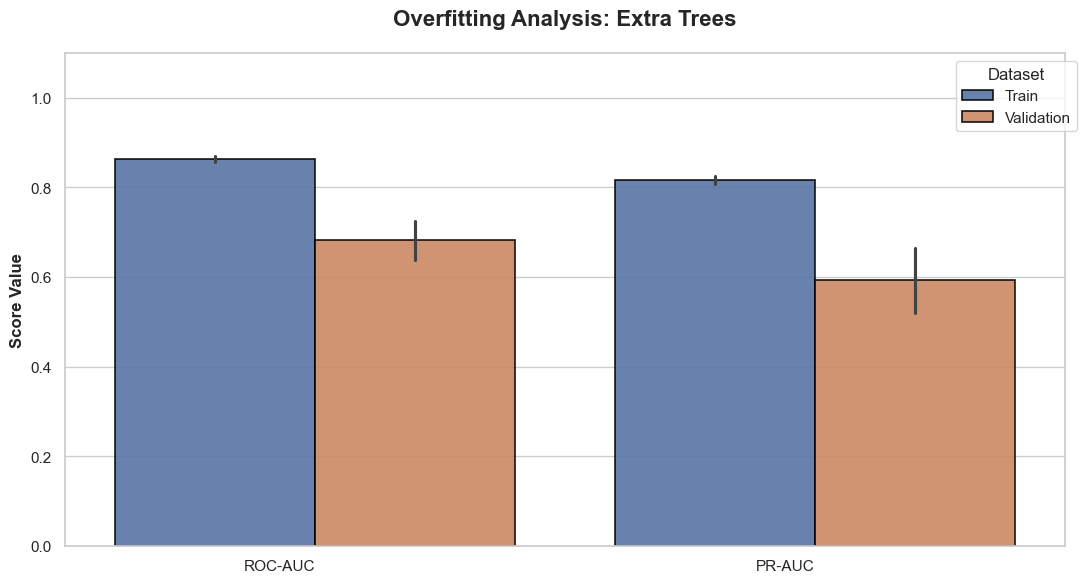

In [33]:
plot_overfitting_bars(df_cv_results=cv_results_ET, 
                    title="Extra Trees", 
                    output_dir=results_path, 
                    identifier="ET")


#### Adaptative Boosting

Define the parameter distributions and set up the pipeline:

In [34]:
# Hyperparameters search space
params_dist_AB = {
    'clf__n_estimators': randint(50, 301),
    'clf__learning_rate': uniform(0.01, 1)
}

# Get the preprocessor
preprocessor_AB = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_AB = Pipeline(steps=[
    ('preprocessor', preprocessor_AB),
    ('clf', AdaBoostClassifier(random_state=seed, estimator=None))
])

Train and optimize the model:

In [35]:
(
optimized_AB, 
cv_results_AB,
fpr_AB, tpr_AB,
precs_AB, recs_AB
) = optimize_model_random_search(
    pipeline=pipe_AB, 
    param_distributions=params_dist_AB, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [36]:
save_model(fitted_pipeline=optimized_AB, output_dir=results_path, identifier="AB")

,Hyperparameter,Optimal Value
1,learning_rate,0.424261
2,n_estimators,122.000000
3,random_state,7214.000000


Check the overfitting:

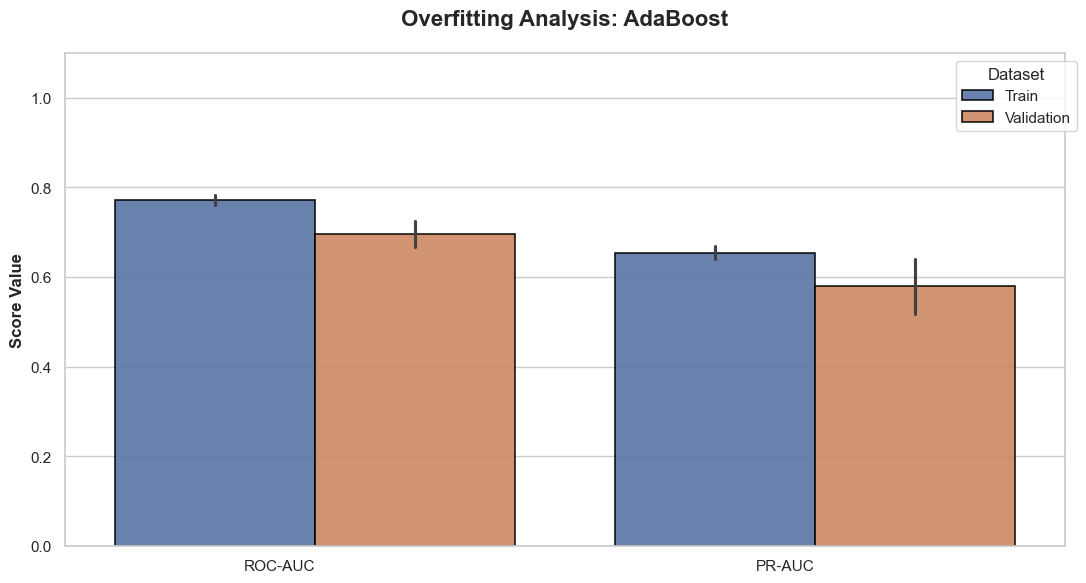

In [37]:
plot_overfitting_bars(df_cv_results=cv_results_AB, 
                    title="AdaBoost", 
                    output_dir=results_path, 
                    identifier="AB")

#### Gradient Boosting

Define the parameter distributions and set up the pipeline:

In [38]:
params_dist_GB = {
    'clf__n_estimators': randint(50, 301),
    'clf__max_depth': randint(3, 11),
    'clf__subsample': uniform(0.5, 0.5),
    'clf__learning_rate': loguniform(0.01, 0.3), 
    'clf__max_features': uniform(0.5, 0.5), 
    'clf__min_samples_leaf': randint(1, 6) 
}

# Get the preprocessor
preprocessor_GB = get_trees_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_GB = Pipeline(steps=[
    ('preprocessor', preprocessor_GB),
    ('clf', GradientBoostingClassifier(
        random_state=seed 
    ))
])

Train and optimize the model:

In [39]:
(
optimized_GB, 
cv_results_GB,
fpr_GB, tpr_GB,
precs_GB, recs_GB
) = optimize_model_random_search(
    pipeline=pipe_GB, 
    param_distributions=params_dist_GB, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [40]:
save_model(fitted_pipeline=optimized_GB, output_dir=results_path, identifier="GB")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,deprecated
3,learning_rate,0.015664
4,loss,log_loss
5,max_depth,3
6,max_features,0.593177
7,min_impurity_decrease,0.0
8,min_samples_leaf,1
9,min_samples_split,2
10,min_weight_fraction_leaf,0.0


Check the overfitting:

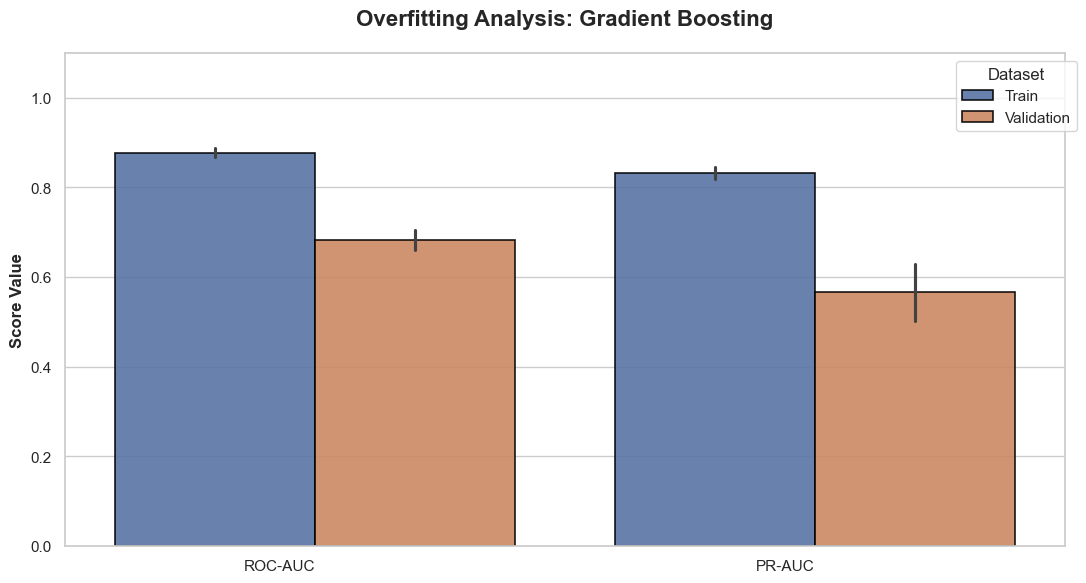

In [41]:
plot_overfitting_bars(df_cv_results=cv_results_GB, 
                    title="Gradient Boosting", 
                    output_dir=results_path, 
                    identifier="GB")

#### Multi-Layer Perceptron

Define the parameter distributions and set up the pipeline:

In [42]:
from sklearn.neural_network import MLPClassifier

# Hyperparameters search space
params_dist_MLP = {
    'clf__hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100), (200, 100)],
    'clf__alpha': loguniform(1e-5, 1e-1),
    'clf__learning_rate_init': loguniform(0.001, 0.01),
    'clf__batch_size': [16, 32, 64],
    'clf__activation': ['relu', 'tanh'],
    'clf__solver': ['adam', 'sgd']
}

# Get the preprocessor
preprocessor_MLP = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_MLP = Pipeline(steps=[
    ('preprocessor', preprocessor_MLP),
    ('clf', MLPClassifier(random_state=seed, max_iter=1000, early_stopping=True, validation_fraction=0.1))
])

Train and optimize the model:

In [43]:
(
optimized_MLP, 
cv_results_MLP,
fpr_MLP, tpr_MLP,
precs_MLP, recs_MLP
) = optimize_model_random_search(
    pipeline=pipe_MLP, 
    param_distributions=params_dist_MLP, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=100,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [44]:
save_model(fitted_pipeline=optimized_MLP, output_dir=results_path, identifier="MLP")


,Hyperparameter,Optimal Value
1,activation,tanh
2,alpha,0.001786
3,batch_size,16
4,beta_1,0.9
5,beta_2,0.999
6,early_stopping,True
7,epsilon,0.0
8,hidden_layer_sizes,"(100,)"
9,learning_rate,constant
10,learning_rate_init,0.004535


Check the overfitting:

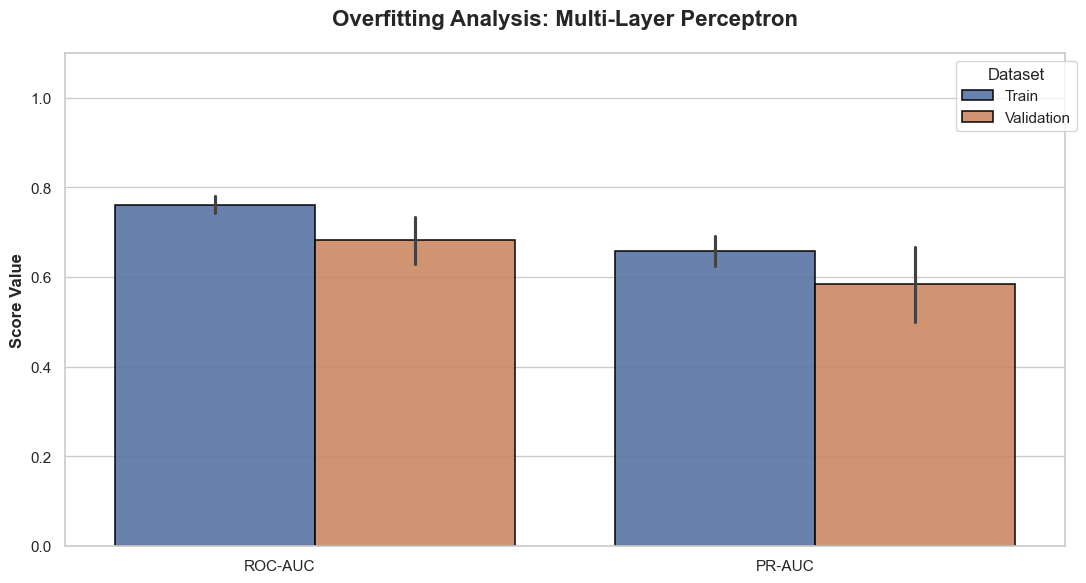

In [45]:
plot_overfitting_bars(df_cv_results=cv_results_MLP, 
                    title="Multi-Layer Perceptron", 
                    output_dir=results_path, 
                    identifier="MLP")


## Save results

In [46]:
models = ["Elastic Net", "SVM", "Decision Tree", "Random Forest", "Extra Trees", "AdaBoost", "Gradient Boost", "MLP"]

models_dict = {
    "Elastic Net": cv_results_EN,
    "SVM": cv_results_SVM,
    "Decision Tree": cv_results_DT,
    "Random Forest": cv_results_RF,
    "Extra Trees": cv_results_ET,
    "AdaBoost": cv_results_GB,
    "AdaBoost": cv_results_AB,
    "Gradient Boost": cv_results_GB,
    "MLP": cv_results_MLP
}


### Main metrics

In [47]:
results = save_metrics_results(models_dict=models_dict, output_dir=results_path)

results.head()

,Model,Metric,Dataset,Score
0,Elastic Net,ROC-AUC,Train,0.752590
1,Elastic Net,ROC-AUC,Validation,0.672136
2,Elastic Net,ROC-AUC,Train,0.756359
3,Elastic Net,ROC-AUC,Validation,0.641727
4,Elastic Net,ROC-AUC,Train,0.721211


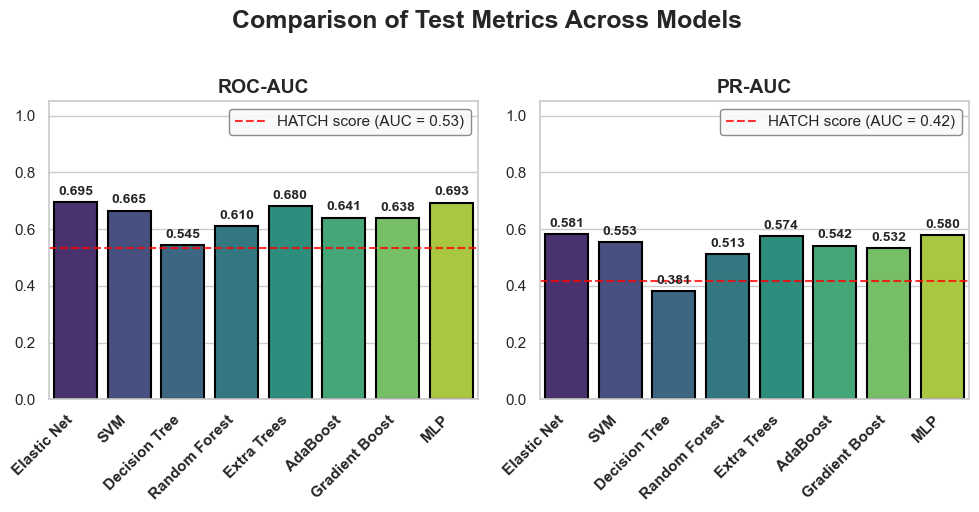

In [48]:
plot_metrics_bars(results, 
                metrics=['ROC-AUC', 'PR-AUC'],
                baselines=[roc_auc_hatch, pr_auc_hatch],
                output_dir=results_path)

### ROC and PR curves

Join the metrics into a csv file:

In [49]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_DT, fpr_RF, fpr_ET, fpr_AB, fpr_GB, fpr_MLP]
tpr = [tpr_EN, tpr_SVM, tpr_DT, tpr_RF, tpr_ET, tpr_AB, tpr_GB, tpr_MLP]

roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', 
                                output_dir=results_path)

# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_DT, precs_RF, precs_ET, precs_AB, precs_GB, precs_MLP]
recs = [recs_EN, recs_SVM, recs_DT, recs_RF, recs_ET, recs_AB, recs_GB, recs_MLP]

pr_results = save_curves_results(models, recs, precs, curve_type='pr', 
                                output_dir=results_path)


Plot ROC curves:

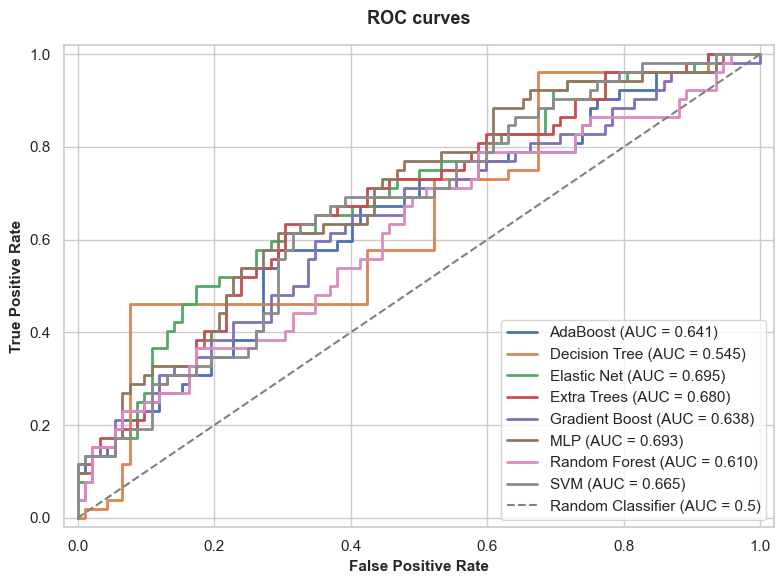

In [50]:
plot_model_curves(roc_results, 
                x_col='False Positive Rate', y_col='True Positive Rate', 
                curve_type='roc', title="ROC curves",
                output_dir=results_path)

Plot PR curves:

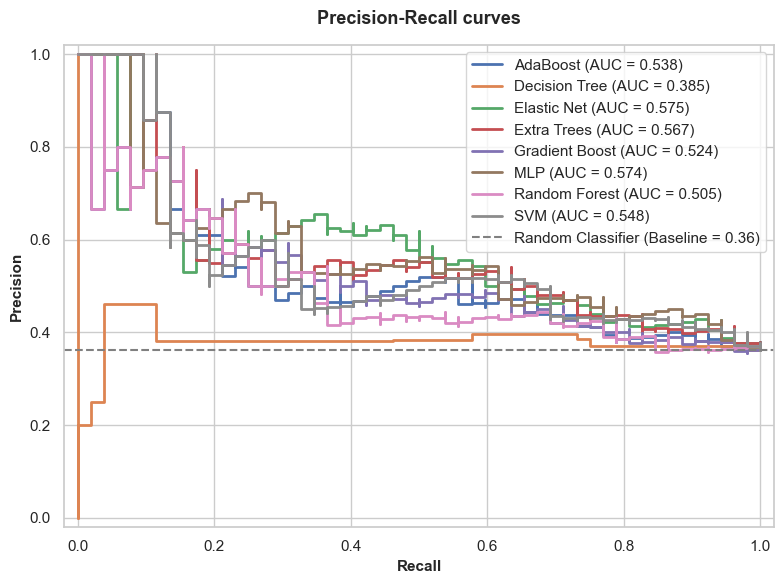

In [51]:
# Use the actual prevalence for the random classifier baseline
test_prevalence = y_test.astype(float).mean()

plot_model_curves(pr_results, 
                x_col='Recall', y_col='Precision', 
                curve_type='pr', title="Precision-Recall curves",
                prevalence=test_prevalence,
                output_dir=results_path)
